# 260410
Cubic loop model のトイモデル計算

## 3 by 3 OBC

### Google Drive image
<img src="images/drive-image.jpg" alt="drive-image" width="320">

In [7]:
from pathlib import Path
import requests

file_id = "1vy_O0-VKBX76QTKeytXg8IFQN0TXwOdb"
download_url = f"https://drive.usercontent.google.com/download?id={file_id}&export=view"

img_dir = Path("images")
img_dir.mkdir(exist_ok=True)
img_path = img_dir / "drive-image.jpg"

r = requests.get(download_url, timeout=30)
r.raise_for_status()
img_path.write_bytes(r.content)

print(f"saved: {img_path}")
print(f"bytes: {img_path.stat().st_size}")

saved: images/drive-image.jpg
bytes: 153644


In [24]:
def Weight_i_g0(x, n):
    return n**9

In [45]:
def Weight_f_g0(x, n):
    return 1

In [25]:
def Weight_i_g1(x, n):
    return (x**4) * (n**6)

In [13]:
def Weight_f_g1(x, n):
    return (x**4) * n

In [26]:
def Weight_i_g2(x, n):
    return (x**6) * (n**4)

In [15]:
def Weight_f_g2(x, n):
    return (x**6) * n

In [27]:
def Weight_i_g3(x, n):
    return (x**6) * (n**4)

In [17]:
def Weight_f_g3(x, n):
    return (x**6) * n

In [28]:
def Weight_i_g4(x, n):
    return (x**8) * (n**3)

In [19]:
def Weight_f_g4(x, n):
    return (x**8) * (n**2)

In [29]:
def Weight_i_g5(x, n):
    return (x**8) * (n**2)

In [21]:
def Weight_f_g5(x, n):
    return (x**8) * n

In [30]:
def Weight_i_g6(x, n):
    return (x**8) * (n**2)

In [23]:
def Weight_f_g6(x, n):
    return (x**8) * n

In [33]:
def PF_i(x, n):
    func =  Weight_i_g0(x, n) + 4 * Weight_i_g1(x, n) + 2 * Weight_i_g2(x, n) + 2 * Weight_i_g3(x, n) \
        + 2 * Weight_i_g4(x, n) + 4 * Weight_i_g5(x, n) + Weight_i_g6(x, n)
    return (2**9) * func

In [46]:
def PF_f(x, n):
    func =  Weight_f_g0(x, n) + 4 * Weight_f_g1(x, n) + 2 * Weight_f_g2(x, n) + 2 * Weight_f_g3(x, n) \
        + 2 * Weight_f_g4(x, n) + 4 * Weight_f_g5(x, n) + Weight_f_g6(x, n)
    return (2**9) * (n**9) * func

saved: pf_diff_csv/PF_diff_n1.csv
saved: pf_diff_csv/PF_diff_n2.csv
saved: pf_diff_csv/PF_diff_n3.csv


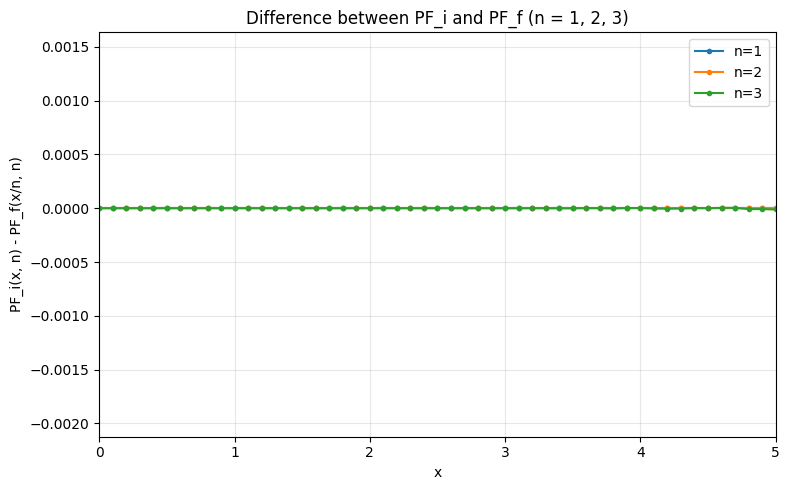

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

x_max = 10.0
x_values = np.arange(0.0, x_max + 1e-9, 0.1)
n_values = [1, 2, 3]

out_dir = Path("pf_diff_csv")
out_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 5))
for n in n_values:
    y_values = np.array([PF_i(x, n) - PF_f(x / n, n) for x in x_values], dtype=float)
    plt.plot(x_values, y_values, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

    csv_path = out_dir / f"PF_diff_n{n}.csv"
    data = np.column_stack((x_values, y_values))
    np.savetxt(csv_path, data, delimiter=",", header="x,PF_i_minus_PF_f", comments="")
    print(f"saved: {csv_path}")

plt.xlabel("x")
plt.ylabel("PF_i(x, n) - PF_f(x/n, n)")
plt.title("Difference between PF_i and PF_f (n = 1, 2, 3)")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
PF_i(5, 2) - PF_f(5/2, 2) 

0.0

In [51]:
PF_i(6, 3) - PF_f(6/3, 3) 

0.0

In [50]:
PF_i(5, 4) - PF_f(5/4, 4) 

0.0